# Mini Project 2
The objectives of this mini-project are to:
1. Apply predictive modelling on an area of your choice
2. Prepare you for the Capstone project
3. Understand your learning gaps
 
Choose a dataset (at least a few hundred rows) or select a question and identify and gather the data you need. 
Follow steps presented in the course so far:
1. Perform EDA on the data
2. Select the outcome/response variable
3. Select features (optionally perform feature engineering)
4. Select approaches/models
5. Apply the models and evaluate them
        
Present from slides on:
1. Business aspects of the project
2. Explore the data and be creative about what insights you could draw from it.
Outcomes
1. Potential additional insights that can be obtained from available data
2. Data analysis and Machine Learning techniques used

# Importing models needed to conduct Linear Regression

In [213]:
#Importing libraies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# EDA and Data Cleaning

In [144]:
#reading in data file
Absent = 'absenteeism_at_work.csv'
Absent_df = pd.DataFrame(pd.read_csv(Absent, sep = ';', index_col = 'ID'))
Absent_df.head()

,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,Hit target,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
ID,,,,,,,,,,,,,,,,,,,,
11,26,7,3,1,289,36,13,33,239.554,97,0,1,2,1,0,1,90,172,30,4
36,0,7,3,1,118,13,18,50,239.554,97,1,1,1,1,0,0,98,178,31,0
3,23,7,4,1,179,51,18,38,239.554,97,0,1,0,1,0,0,89,170,31,2
7,7,7,5,1,279,5,14,39,239.554,97,0,1,2,1,1,0,68,168,24,4
11,23,7,5,1,289,36,13,33,239.554,97,0,1,2,1,0,1,90,172,30,2


In [145]:
# change the names of the columns and inspect again
Absent_df.columns = ['Reason_absent', 'Month_absent', 'Day_absent',
                     'Seasons', 'Trans_expense', 'Distance_to_work', 
                     'Service_time', 'Age', 'Workload', 'Hit_target', 
                     'Disciplinary', 'Education', 'Childern', 'Drinker', 
                     'Smoker', 'Pet', 'Weight', 'Height', 'BMI', 'Absent_hours']
Absent_df = Absent_df[['Absent_hours'] + [c for c in Absent_df.columns if c != 'Absent_hours']] #Moving Absent_hours column to begin of the DF
print(Absent_df.dtypes)
Absent_df.head()

Absent_hours          int64
Reason_absent         int64
Month_absent          int64
Day_absent            int64
Seasons               int64
Trans_expense         int64
Distance_to_work      int64
Service_time          int64
Age                   int64
Workload            float64
Hit_target            int64
Disciplinary          int64
Education             int64
Childern              int64
Drinker               int64
Smoker                int64
Pet                   int64
Weight                int64
Height                int64
BMI                   int64
dtype: object


,Absent_hours,Reason_absent,Month_absent,Day_absent,Seasons,Trans_expense,Distance_to_work,Service_time,Age,Workload,Hit_target,Disciplinary,Education,Childern,Drinker,Smoker,Pet,Weight,Height,BMI
ID,,,,,,,,,,,,,,,,,,,,
11,4,26,7,3,1,289,36,13,33,239.554,97,0,1,2,1,0,1,90,172,30
36,0,0,7,3,1,118,13,18,50,239.554,97,1,1,1,1,0,0,98,178,31
3,2,23,7,4,1,179,51,18,38,239.554,97,0,1,0,1,0,0,89,170,31
7,4,7,7,5,1,279,5,14,39,239.554,97,0,1,2,1,1,0,68,168,24
11,2,23,7,5,1,289,36,13,33,239.554,97,0,1,2,1,0,1,90,172,30


In [146]:
#Converting Reason_absent into dummy variables for linear regression model
Absent_clean = pd.get_dummies(Absent_df, columns=['Reason_absent'], prefix='Reason', dtype=int)
Absent_clean

,Absent_hours,Month_absent,Day_absent,Seasons,Trans_expense,Distance_to_work,Service_time,Age,Workload,Hit_target,...,Reason_18,Reason_19,Reason_21,Reason_22,Reason_23,Reason_24,Reason_25,Reason_26,Reason_27,Reason_28
ID,,,,,,,,,,,,,,,,,,,,,
11,4,7,3,1,289,36,13,33,239.554,97,...,0,0,0,0,0,0,0,1,0,0
36,0,7,3,1,118,13,18,50,239.554,97,...,0,0,0,0,0,0,0,0,0,0
3,2,7,4,1,179,51,18,38,239.554,97,...,0,0,0,0,1,0,0,0,0,0
7,4,7,5,1,279,5,14,39,239.554,97,...,0,0,0,0,0,0,0,0,0,0
11,2,7,5,1,289,36,13,33,239.554,97,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,8,7,3,1,289,36,13,33,264.604,93,...,0,0,0,0,0,0,0,0,0,0
1,4,7,3,1,235,11,14,37,264.604,93,...,0,0,0,0,0,0,0,0,0,0
4,0,0,3,1,118,14,13,40,271.219,95,...,0,0,0,0,0,0,0,0,0,0


In [147]:
#DF information
Absent_clean.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 11 to 35
Data columns (total 47 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Absent_hours      740 non-null    int64  
 1   Month_absent      740 non-null    int64  
 2   Day_absent        740 non-null    int64  
 3   Seasons           740 non-null    int64  
 4   Trans_expense     740 non-null    int64  
 5   Distance_to_work  740 non-null    int64  
 6   Service_time      740 non-null    int64  
 7   Age               740 non-null    int64  
 8   Workload          740 non-null    float64
 9   Hit_target        740 non-null    int64  
 10  Disciplinary      740 non-null    int64  
 11  Education         740 non-null    int64  
 12  Childern          740 non-null    int64  
 13  Drinker           740 non-null    int64  
 14  Smoker            740 non-null    int64  
 15  Pet               740 non-null    int64  
 16  Weight            740 non-null    int64  
 17  Height       

In [218]:
Absent_clean['Absent_hours'].value_counts()

Absent_hours
8      208
2      157
3      112
1       88
4       60
0       44
16      19
24      16
40       7
5        7
32       6
64       3
80       3
120      3
56       2
112      2
7        1
104      1
48       1
Name: count, dtype: int64

In [221]:
Absent_df['Reason_absent'].value_counts()

Reason_absent
23    149
28    112
27     69
13     55
0      43
19     40
22     38
26     33
25     31
11     26
10     25
18     21
14     19
1      16
7      15
6       8
12      8
21      6
8       6
9       4
24      3
5       3
16      3
15      2
4       2
17      1
3       1
2       1
Name: count, dtype: int64

In [148]:
#DF description
Absent_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Absent_hours,740.0,6.924324,13.330998,0.000,2.000,3.000,8.000,120.000
Month_absent,740.0,6.324324,3.436287,0.000,3.000,6.000,9.000,12.000
Day_absent,740.0,3.914865,1.421675,2.000,3.000,4.000,5.000,6.000
Seasons,740.0,2.544595,1.111831,1.000,2.000,3.000,4.000,4.000
Trans_expense,740.0,221.329730,66.952223,118.000,179.000,225.000,260.000,388.000
Distance_to_work,740.0,29.631081,14.836788,5.000,16.000,26.000,50.000,52.000
Service_time,740.0,12.554054,4.384873,1.000,9.000,13.000,16.000,29.000
Age,740.0,36.450000,6.478772,27.000,31.000,37.000,40.000,58.000
Workload,740.0,271.490235,39.058116,205.917,244.387,264.249,294.217,378.884
Hit_target,740.0,94.587838,3.779313,81.000,93.000,95.000,97.000,100.000


In [216]:
#Dropping Month_absent, Day_absent, and Seasons from DF to have only one target avariable 
#for linear Regression model
Absent_hour = Absent_clean.drop(['Month_absent', 'Day_absent', 'Seasons'], axis=1)

In [150]:
#Run correlation calculations
Absent_hour_corr = Absent_hour.corr()
Absent_hour_corr 

,Absent_hours,Trans_expense,Distance_to_work,Service_time,Age,Workload,Hit_target,Disciplinary,Education,Childern,...,Reason_18,Reason_19,Reason_21,Reason_22,Reason_23,Reason_24,Reason_25,Reason_26,Reason_27,Reason_28
Absent_hours,1.000000,0.027585,-0.088363,0.019029,0.065760,0.024749,0.026695,-0.124248,-0.046235,0.113756,...,0.043733,0.202776,-0.007404,0.013731,-0.153727,0.005152,-0.054001,0.005650,-0.111905,-0.124684
Trans_expense,0.027585,1.000000,0.262183,-0.349887,-0.227542,0.005438,-0.080193,0.109222,-0.055065,0.383001,...,-0.021277,0.042410,-0.044588,0.272651,-0.052640,0.064529,-0.038231,0.082597,-0.240944,-0.028230
Distance_to_work,-0.088363,0.262183,1.000000,0.131730,-0.145886,-0.068677,-0.013865,-0.056527,-0.259605,0.054230,...,-0.044049,0.012800,0.005299,0.110677,-0.057055,0.027406,-0.098067,-0.055118,0.159062,0.134103
Service_time,0.019029,-0.349887,0.131730,1.000000,0.670979,-0.000668,-0.007840,-0.000221,-0.213000,-0.047128,...,-0.001180,-0.083414,0.060784,-0.173335,-0.039647,0.006493,-0.023360,-0.004906,0.115362,0.086863
Age,0.065760,-0.227542,-0.145886,0.670979,1.000000,-0.039425,-0.039224,0.104304,-0.221882,0.056984,...,0.030859,-0.036922,0.010008,-0.136271,-0.065088,-0.033997,-0.009324,0.046667,-0.046694,0.069071
Workload,0.024749,0.005438,-0.068677,-0.000668,-0.039425,1.000000,-0.089445,0.029026,-0.074960,0.027820,...,-0.008102,0.028897,-0.003797,-0.018347,-0.067863,-0.040874,-0.085834,-0.015561,-0.065491,-0.011186
Hit_target,0.026695,-0.080193,-0.013865,-0.007840,-0.039224,-0.089445,1.000000,-0.147971,0.101062,-0.014091,...,0.029425,0.030834,0.005877,0.031875,-0.062983,-0.060609,0.087115,0.011443,0.167894,-0.080706
Disciplinary,-0.124248,0.109222,-0.056527,-0.000221,0.104304,0.029026,-0.147971,1.000000,-0.059298,0.072096,...,-0.040853,-0.057143,-0.021613,-0.055617,-0.120027,-0.015251,-0.049985,-0.051645,-0.076656,-0.100951
Education,-0.046235,-0.055065,-0.259605,-0.213000,-0.221882,-0.074960,0.101062,-0.059298,1.000000,-0.188622,...,0.046816,-0.032650,0.095160,0.026465,-0.037526,-0.027680,0.099771,-0.035347,0.068107,-0.155199
Childern,0.113756,0.383001,0.054230,-0.047128,0.056984,0.027820,-0.014091,0.072096,-0.188622,1.000000,...,0.026709,0.093872,-0.015285,0.124272,-0.030142,0.057020,0.008685,0.085735,-0.280712,0.047680


In [204]:
#Finding the top 10 highest correlation with Absent_hours
Absent_hour_corr['Absent_hours'].nlargest(n=11)

Absent_hours    1.000000
Reason_19       0.202776
Reason_9        0.194101
Reason_13       0.178344
Height          0.144420
Reason_12       0.129093
Childern        0.113756
Reason_6        0.113399
Age             0.065760
Drinker         0.065067
Reason_11       0.064441
Name: Absent_hours, dtype: float64

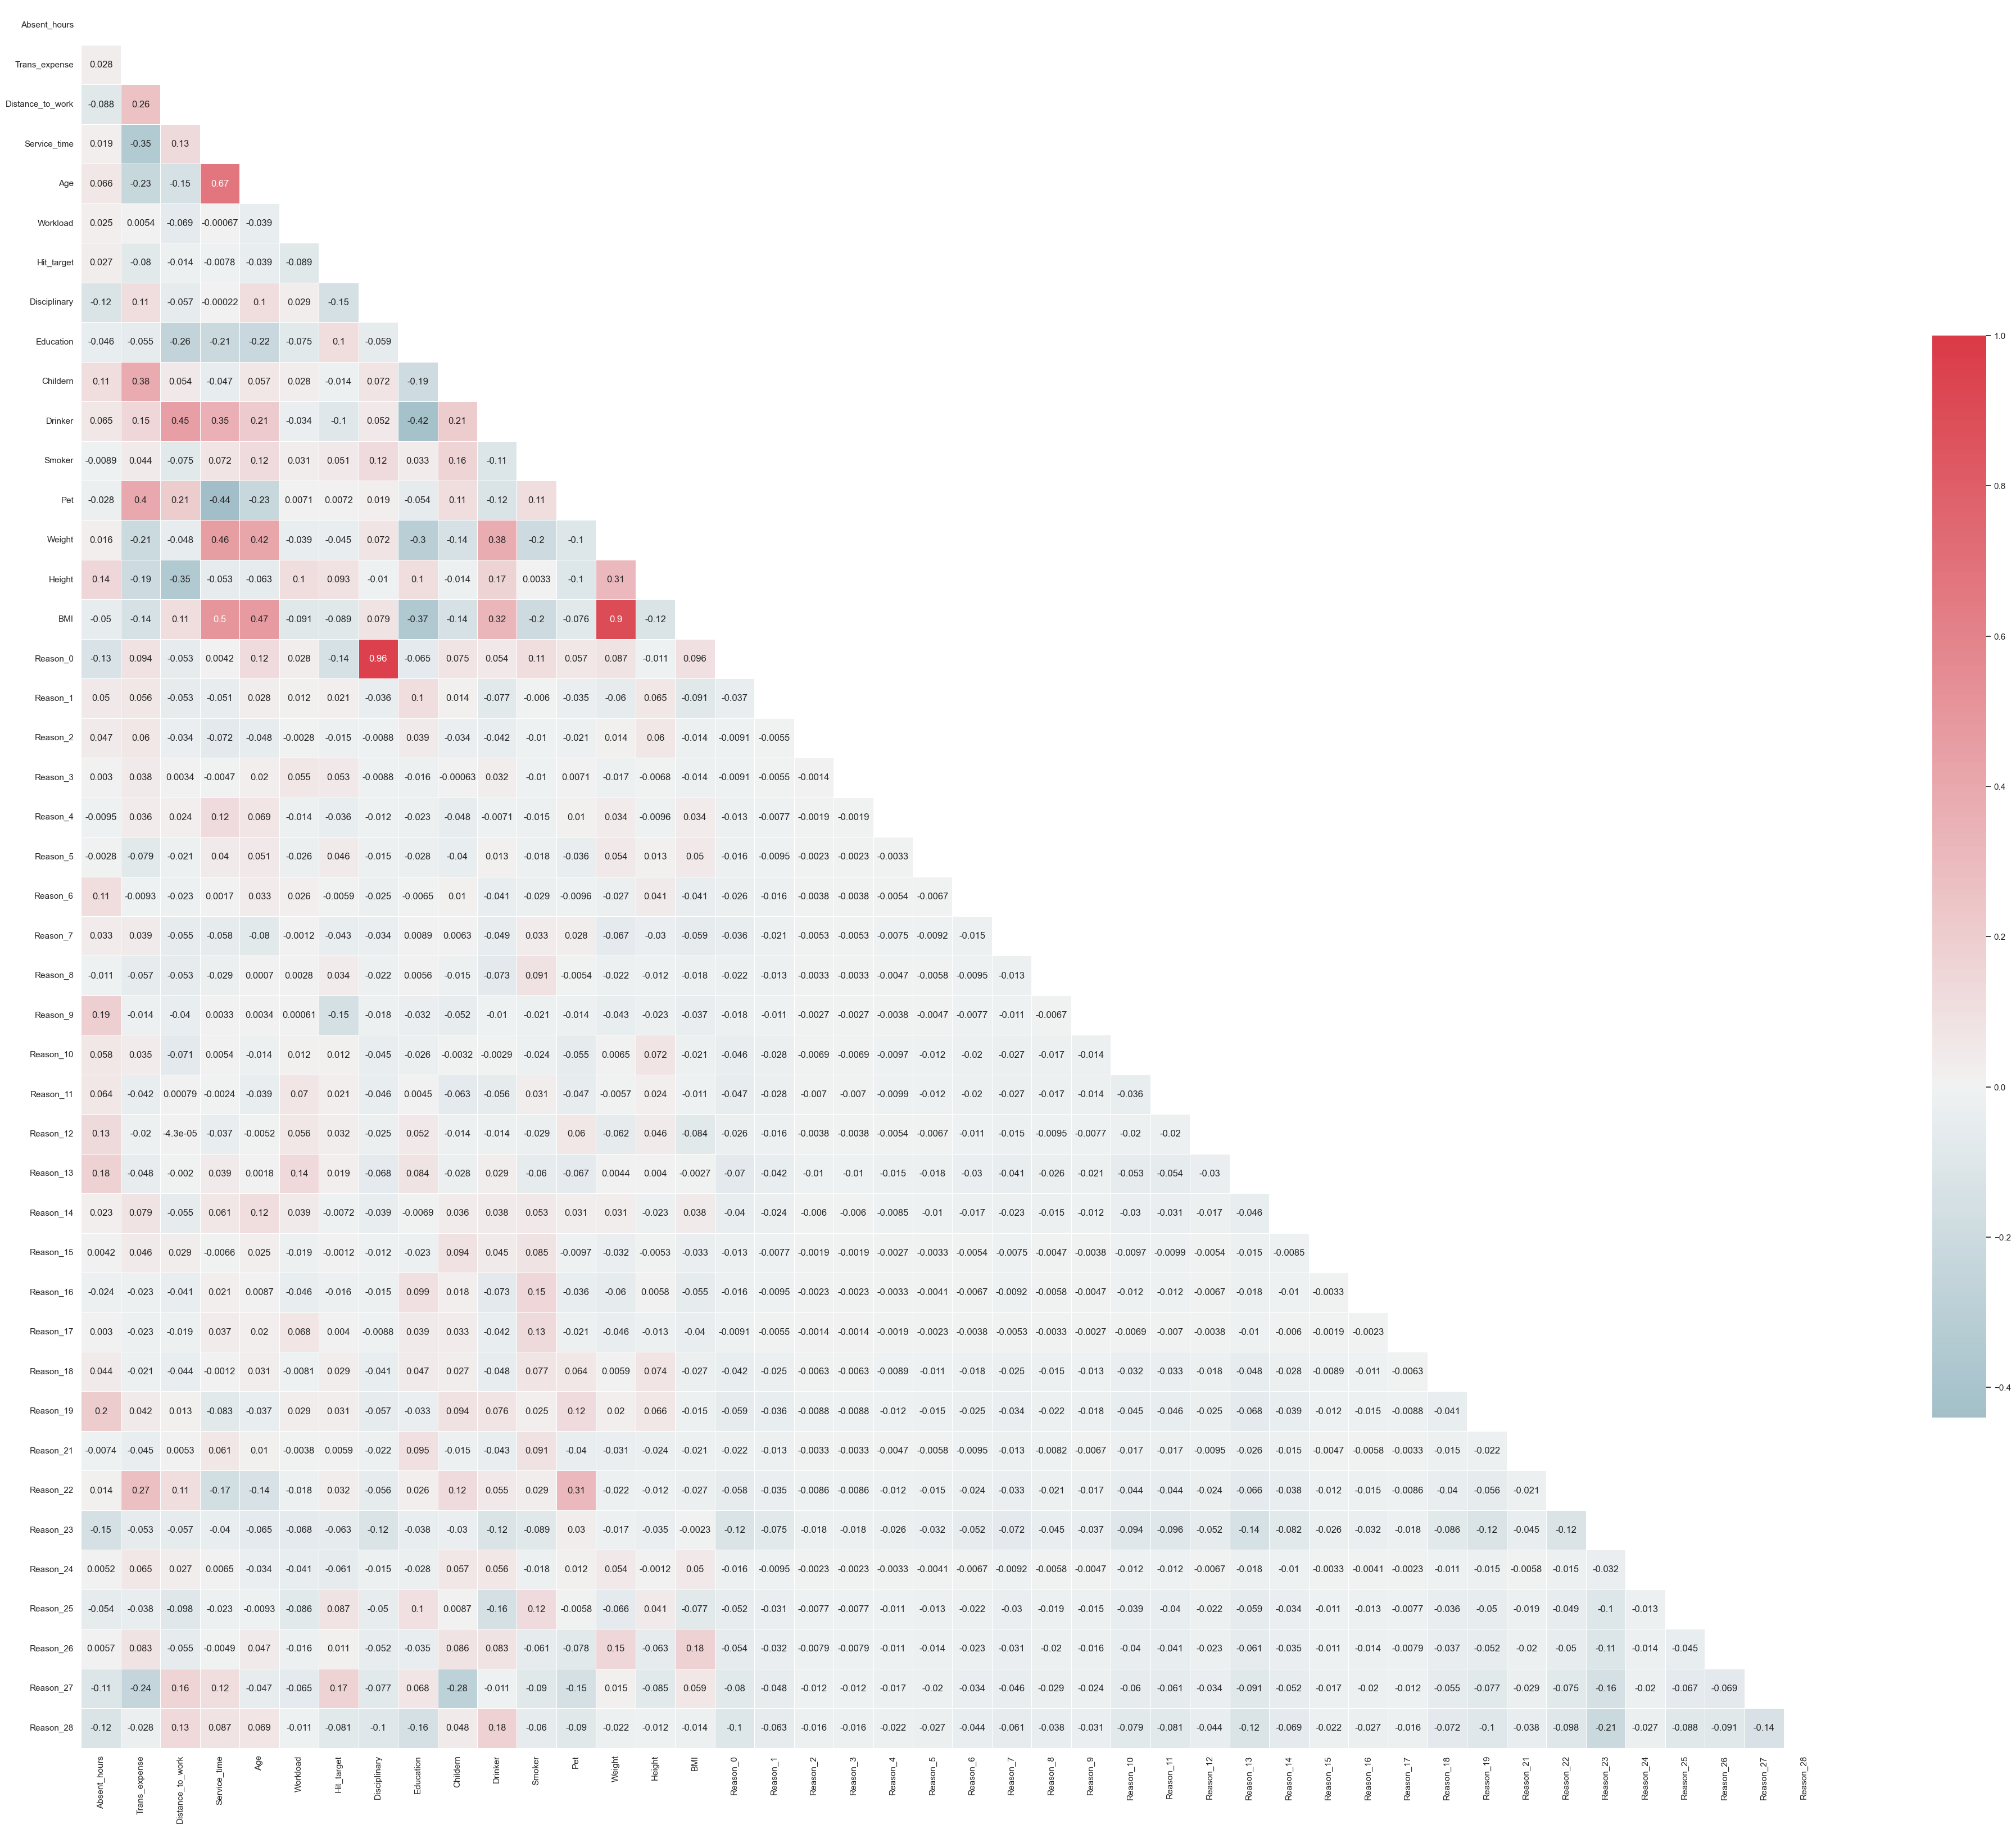

In [228]:
# Copied code from seaborn examples
# https://seaborn.pydata.org/examples/many_pairwise_correlations.html
sns.set(style="white")

# Generate a mask for the upper triangle
mask = np.zeros_like(Absent_hour.corr())
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(50, 50))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(Absent_hour.corr(numeric_only = True), mask=mask, cmap=cmap, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)

plt.show();

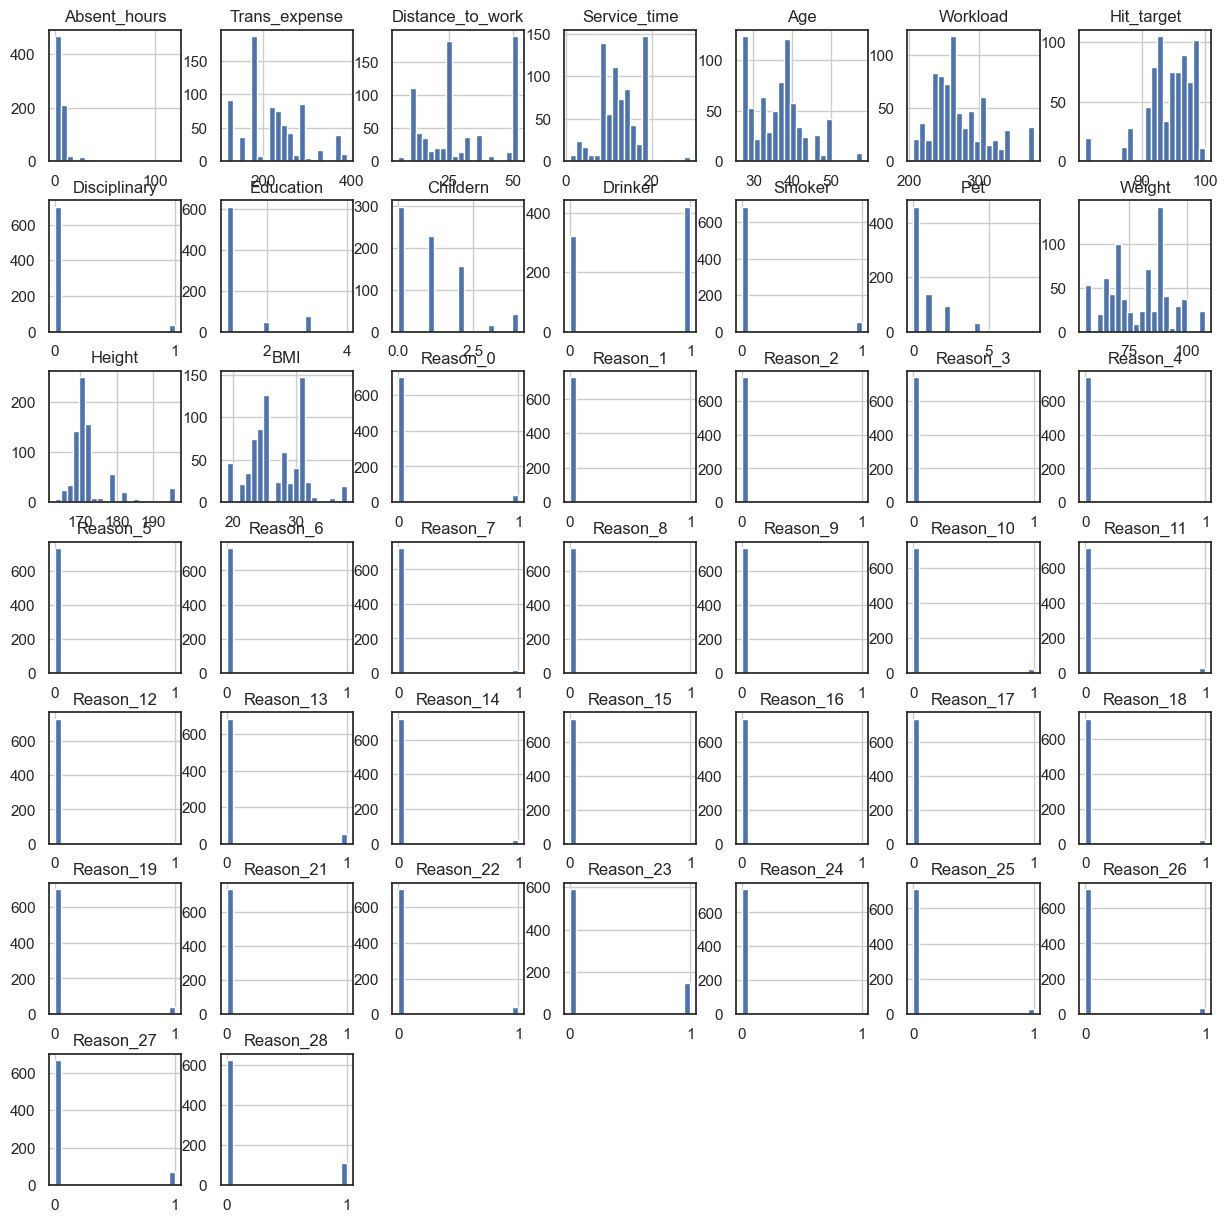

In [151]:
#Plot histograms for Absent_hour dataframe
Absent_hour.hist(bins=20, figsize=(15, 15))
plt.show()

# Defining Features and Target for Linear Regression model

In [152]:
#Defining features
X = Absent_hour.iloc[:, 1:]
X

,Trans_expense,Distance_to_work,Service_time,Age,Workload,Hit_target,Disciplinary,Education,Childern,Drinker,...,Reason_18,Reason_19,Reason_21,Reason_22,Reason_23,Reason_24,Reason_25,Reason_26,Reason_27,Reason_28
ID,,,,,,,,,,,,,,,,,,,,,
11,289,36,13,33,239.554,97,0,1,2,1,...,0,0,0,0,0,0,0,1,0,0
36,118,13,18,50,239.554,97,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,179,51,18,38,239.554,97,0,1,0,1,...,0,0,0,0,1,0,0,0,0,0
7,279,5,14,39,239.554,97,0,1,2,1,...,0,0,0,0,0,0,0,0,0,0
11,289,36,13,33,239.554,97,0,1,2,1,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,289,36,13,33,264.604,93,0,1,2,1,...,0,0,0,0,0,0,0,0,0,0
1,235,11,14,37,264.604,93,0,3,1,0,...,0,0,0,0,0,0,0,0,0,0
4,118,14,13,40,271.219,95,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [153]:
#Defining target as Absent_hours
y = Absent_hour['Absent_hours']
y

ID
11    4
36    0
3     2
7     4
11    2
     ..
11    8
1     4
4     0
8     0
35    0
Name: Absent_hours, Length: 740, dtype: int64

In [155]:
## Create training and testing subsets - 70/30 split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [156]:
X_train.shape

(518, 43)

# Using Forward Feature Selection to pick a good model

In [157]:
## Flag intermediate output

show_steps = True   # for testing/debugging
# show_steps = False  # without showing steps

In [158]:
# start with no predictors
included = []
# keep track of model and parameters
best = {'feature': '', 'r2': 0, 'a_r2': 0}
# create a model object to hold the modelling parameters
model = LinearRegression()
# get the number of cases in the training data
n = X_train.shape[0]

r2_list = []
adjusted_r2_list = []

while True:
    changed = False

    if show_steps:
        print('')

    # list the features to be evaluated
    excluded = list(set(X.columns) - set(included))

    if show_steps:
        print(f"(Step) Excluded = {', '.join(excluded)}")

    # for each remaining feature to be evaluated
    for new_column in excluded:

        if show_steps:
            print(f"(Step) Trying {new_column}...")
            print(f"(Step) - Features = {', '.join(included + [new_column])}")

        # fit the model with the Training data
        fit = model.fit(X_train[included + [new_column]], y_train)
        # calculate the score (R^2 for Regression)
        r2 = model.score(X_train[included + [new_column]], y_train)

        # number of predictors in this model
        k = len(included) + 1
        # calculate the adjusted R^2
        adjusted_r2 = 1 - ( ( (1 - r2) * (n - 1) ) / (n - k - 1) )

        if show_steps:
            print(f"(Step) - Adjusted R^2: This = {adjusted_r2:.3f}; Best = {best['a_r2']:.3f}")

        # if model improves
        if adjusted_r2 > best['a_r2']:
            # record new parameters
            best = {'feature': new_column, 'r2': r2, 'a_r2': adjusted_r2}
            # flag that found a better model
            changed = True
            if show_steps:
                print(f"(Step) - New Best!   : Feature = {best['feature']}; R^2 = {best['r2']:.3f}; Adjusted R^2 = {best['a_r2']:.3f}")
    # END for

    r2_list.append(best['r2'])
    adjusted_r2_list.append(best['a_r2'])

    # if found a better model after testing all remaining features
    if changed:
        # update control details
        included.append(best['feature'])
        excluded = list(set(excluded) - set(best['feature']))
        print(f"Added feature {best['feature']} with R^2 = {best['r2']:.3f} and adjusted R^2 = {best['a_r2']:.3f}")
    else:
        # terminate if no better model
        print('*'*50)
        break

print('')
print('Resulting features:')
print(', '.join(included))


(Step) Excluded = Reason_27, Reason_0, Reason_23, Hit_target, Age, Reason_1, Reason_14, Reason_13, Reason_16, Disciplinary, Reason_6, Weight, Reason_19, Reason_22, Trans_expense, Education, Reason_9, Distance_to_work, Reason_21, Reason_5, Drinker, Reason_15, Reason_25, Reason_7, Reason_10, Reason_2, Smoker, Workload, Reason_4, Pet, Reason_3, BMI, Childern, Reason_11, Reason_24, Reason_8, Service_time, Height, Reason_26, Reason_12, Reason_18, Reason_17, Reason_28
(Step) Trying Reason_27...
(Step) - Features = Reason_27
(Step) - Adjusted R^2: This = 0.013; Best = 0.000
(Step) - New Best!   : Feature = Reason_27; R^2 = 0.015; Adjusted R^2 = 0.013
(Step) Trying Reason_0...
(Step) - Features = Reason_0
(Step) - Adjusted R^2: This = 0.016; Best = 0.013
(Step) - New Best!   : Feature = Reason_0; R^2 = 0.018; Adjusted R^2 = 0.016
(Step) Trying Reason_23...
(Step) - Features = Reason_23
(Step) - Adjusted R^2: This = 0.021; Best = 0.016
(Step) - New Best!   : Feature = Reason_23; R^2 = 0.023; A

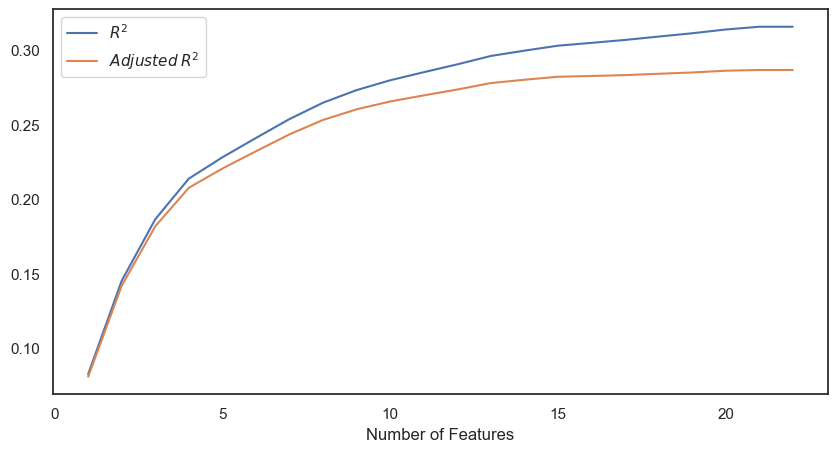

In [159]:
## Chart both R^2 and Adjusted R^2

_range = range(1, len(r2_list)+1)

# define chart size
plt.figure(figsize = (10, 5))
# plot each metric
plt.plot(_range, r2_list, label = '$R^2$')
plt.plot(_range, adjusted_r2_list, label = '$Adjusted \: R^2$')
# add some better visualization
plt.xlabel('Number of Features')
plt.legend()
# output the chart
plt.show()

# Setting features based on Forward Feature Selection and Running Linear Regression Model

In [193]:
#Using features based on forward features selection
feature_cols = ['Reason_19', 'Reason_9', 'Reason_12', 'Reason_6', 'Reason_13', 'Reason_10', 
                'Childern', 'Reason_18', 'Reason_7', 'Reason_0', 'Age', 'Height', 
                'Trans_expense', 'Reason_28', 'Reason_23', 'Education', 'Workload', 
                'BMI', 'Reason_25', 'Reason_27', 'Smoker']
X = Absent_hour[feature_cols]
y = Absent_hour['Absent_hours']

In [194]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [195]:
# Fit and score model on training data

lr = LinearRegression()
lr.fit(X_train, y_train)
lr.score(X_train, y_train)

0.3154353917584748

In [198]:
# Score model on test data
lr.score(X_test, y_test)

0.051094104525197914

# Conducting Cross Validation on Model

In [166]:
# Cross validation
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

# Set up 5-fold cross validation
k_fold = KFold(5, shuffle=True)
train_scores = []
train_rmse = []
test_scores = []
test_rmse = []

for k, (train, test) in enumerate(k_fold.split(X)):

    # Get training and test sets for X and y
    X_train = X.iloc[train, ]
    y_train = y.iloc[train, ]
    X_test = X.iloc[test, ]
    y_test = y.iloc[test, ]

    # Fit model with training set
    lr.fit(X_train, y_train)

    # Make predictions with training and test set
    train_preds = lr.predict(X_train)
    test_preds = lr.predict(X_test)

    # Score R2 and RMSE on training and test sets and store in list
    train_scores.append(lr.score(X_train, y_train))
    test_scores.append(lr.score(X_test, y_test))

    train_rmse.append(root_mean_squared_error(y_train, train_preds))
    test_rmse.append(root_mean_squared_error(y_test, test_preds))

# Create a metrics_df dataframe to display r2 and rmse scores
metrics_df = pd.DataFrame({'Training R2': train_scores,
                           'Test R2': test_scores,
                           'Training RMSE': train_rmse,
                           'Test RMSE': test_rmse},
                          index=[i+1 for i in range(5)])

metrics_df

,Training R2,Test R2,Training RMSE,Test RMSE
1,0.237239,0.203103,11.604261,12.006793
2,0.261436,0.130416,10.226226,16.678266
3,0.276036,-0.402084,12.223806,9.188439
4,0.290696,0.001449,11.138686,13.688251
5,0.238689,0.177594,11.955859,10.575012


In [167]:
metrics_df.describe()

,Training R2,Test R2,Training RMSE,Test RMSE
count,5.000000,5.000000,5.000000,5.000000
mean,0.260819,0.022095,11.429768,12.427352
std,0.023294,0.249515,0.785964,2.905113
min,0.237239,-0.402084,10.226226,9.188439
25%,0.238689,0.001449,11.138686,10.575012
50%,0.261436,0.130416,11.604261,12.006793
75%,0.276036,0.177594,11.955859,13.688251
max,0.290696,0.203103,12.223806,16.678266


# Using StandardScaler to see if there are imporvements in the model

In [219]:
#Using features based on forward features selection for scaling
feature_cols = ['Reason_19', 'Reason_9', 'Reason_12', 'Reason_6', 'Reason_13', 'Reason_10', 
                'Childern', 'Reason_18', 'Reason_7', 'Reason_0', 'Age', 'Height', 
                'Trans_expense', 'Reason_28', 'Reason_23', 'Education', 'Workload', 
                'BMI', 'Reason_25', 'Reason_27', 'Smoker']
X = Absent_hour[feature_cols]
y = Absent_hour['Absent_hours']

In [223]:
from sklearn.metrics import mean_squared_error, r2_score 

#Using scaling on linear regression model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Model Initialization and Training
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 8. Model Evaluation
y_pred = model.predict(X_test_scaled)

# Calculate key evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model score (train): {model.score(X_train_scaled, y_train)}")
print(f"Root Mean Squared Error (RMSE - test): {rmse:.4f}")
print(f"R-squared Score (R² - Test): {r2:.4f}")

Model score (train): 0.3154353917584748
Root Mean Squared Error (RMSE - test): 14.2570
R-squared Score (R² - Test): 0.0511


In [220]:
pd.DataFrame(X_train_scaled)

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,-0.260847,-0.088216,-0.098725,-0.117041,3.504576,-0.189737,0.886540,-0.147296,-0.147296,-0.247942,...,-1.185272,0.391771,-0.405025,-0.489116,-0.433451,-1.286383,1.229167,-0.220416,-0.337607,-0.27735
1,-0.260847,-0.088216,-0.098725,-0.117041,-0.285341,-0.189737,-0.893413,-0.147296,-0.147296,-0.247942,...,1.614488,1.600697,-0.405025,2.044505,1.043705,-0.832051,-0.365452,-0.220416,-0.337607,-0.27735
2,-0.260847,-0.088216,-0.098725,-0.117041,3.504576,-0.189737,-0.893413,-0.147296,-0.147296,-0.247942,...,-0.197121,-0.625496,-0.405025,-0.489116,2.520862,1.908876,-1.732268,-0.220416,-0.337607,-0.27735
3,-0.260847,-0.088216,-0.098725,-0.117041,-0.285341,-0.189737,-0.893413,-0.147296,-0.147296,-0.247942,...,-0.361813,0.362285,-0.405025,2.044505,-0.433451,-0.504520,-0.821057,-0.220416,-0.337607,-0.27735
4,-0.260847,-0.088216,-0.098725,-0.117041,-0.285341,-0.189737,2.666493,-0.147296,-0.147296,-0.247942,...,-0.691197,0.568687,-0.405025,-0.489116,-0.433451,0.345731,-0.821057,-0.220416,-0.337607,-0.27735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,-0.260847,-0.088216,-0.098725,-0.117041,-0.285341,-0.189737,-0.003436,-0.147296,-0.147296,-0.247942,...,-0.197121,1.025720,-0.405025,2.044505,-0.433451,-0.461048,-0.365452,-0.220416,-0.337607,-0.27735
514,-0.260847,-0.088216,-0.098725,-0.117041,-0.285341,-0.189737,-0.003436,-0.147296,-0.147296,-0.247942,...,-0.526505,0.052682,2.468986,-0.489116,-0.433451,-0.254087,-0.593255,-0.220416,-0.337607,-0.27735
515,-0.260847,-0.088216,-0.098725,-0.117041,-0.285341,-0.189737,-0.893413,-0.147296,-0.147296,-0.247942,...,-0.361813,-0.625496,-0.405025,-0.489116,-0.433451,0.614587,1.001364,-0.220416,-0.337607,-0.27735
516,-0.260847,-0.088216,-0.098725,-0.117041,-0.285341,-0.189737,-0.003436,-0.147296,-0.147296,-0.247942,...,-0.526505,0.052682,-0.405025,-0.489116,-0.433451,-0.656131,-0.593255,4.536886,-0.337607,-0.27735


# Using Ridge Regression to if there is an improvement

In [234]:
## Calculate Ridge Regression model

# create a model object to hold the modelling parameters
ridgemodel = Ridge()

# keep track of the intermediate results for coefficients and errors
coefs = []
errors = []

# create a range of alphas to calculate
ridge_alphas = np.logspace(-6, 6, 200)

# Train the model with different regularization strengths
for a in ridge_alphas:
    ridgemodel.set_params(alpha = a)
    ridgemodel.fit(X_train, y_train)
    coefs.append(ridgemodel.coef_)
    errors.append(mean_squared_error(ridgemodel.coef_, model.coef_))

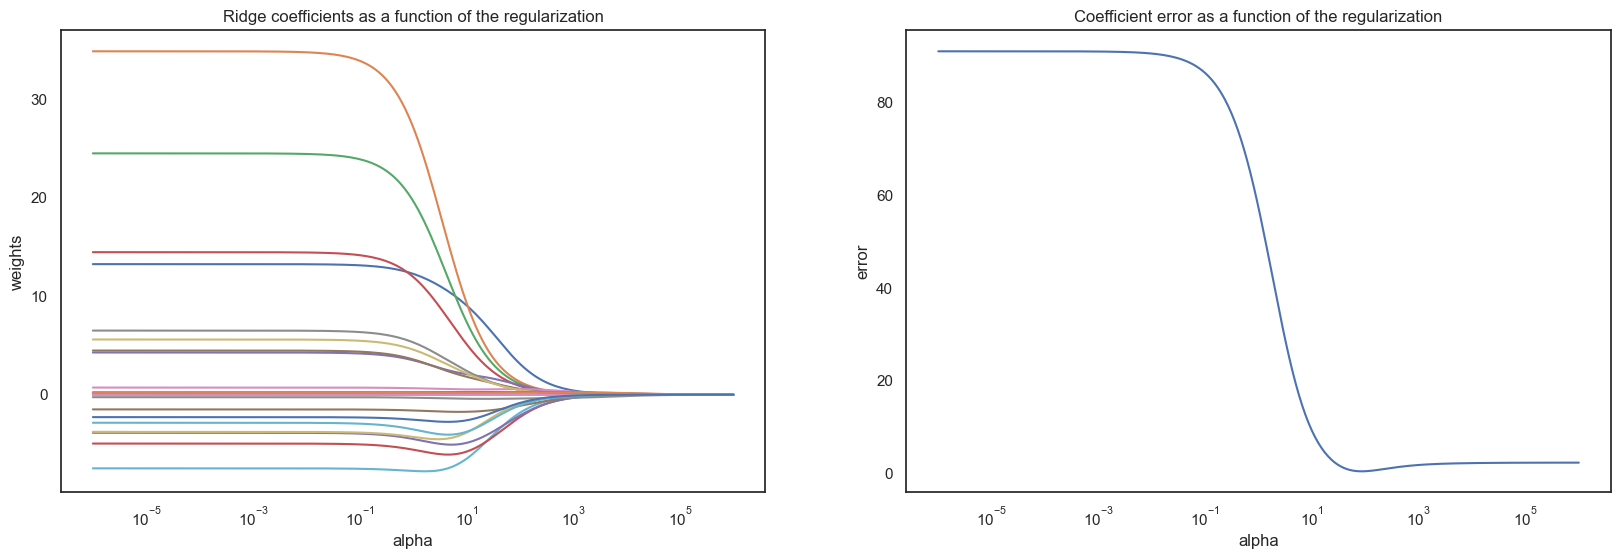

In [235]:
# Display results
plt.figure(figsize = (20, 6))

plt.subplot(121)
ax = plt.gca()
ax.plot(ridge_alphas, coefs)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Ridge coefficients as a function of the regularization')
plt.axis('tight')

plt.subplot(122)
ax = plt.gca()
ax.plot(ridge_alphas, errors)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('error')
plt.title('Coefficient error as a function of the regularization')
plt.axis('tight')

plt.show()

In [243]:
#Score for training data
optimal_ridge = RidgeCV(alphas=ridge_alphas, cv=10)
optimal_ridge.fit(X_train, y_train)
print('Alpha:', optimal_ridge.alpha_)
print('Score:', optimal_ridge.score(X_train, y_train))

Alpha: 8.603464416684492
Score: 0.26523303835044076


In [242]:
#Score for test data
optimal_ridge = RidgeCV(alphas=ridge_alphas, cv=10)
optimal_ridge.fit(X_train, y_train)
print('Alpha:', optimal_ridge.alpha_)
print('Score:', optimal_ridge.score(X_test, y_test))

Alpha: 8.603464416684492
Score: 0.10380856030386443


# Using Lasso Regression to if there is an improvement

In [247]:
## Calculate Lasso Regression model
from sklearn.linear_model import Lasso, LassoCV
# create a model object to hold the modelling parameters
lassomodel = Lasso()

# keep track of the intermediate results for coefficients and errors
coefs = []
errors = []

# create a range of alphas to calculate
lasso_alphas = np.logspace(-6, 6, 200)

# Train the model with different regularization strengths
for a in lasso_alphas:
    lassomodel.set_params(alpha = a)
    lassomodel.fit(X_train, y_train)
    coefs.append(lassomodel.coef_)
    errors.append(mean_squared_error(lassomodel.coef_, model.coef_))

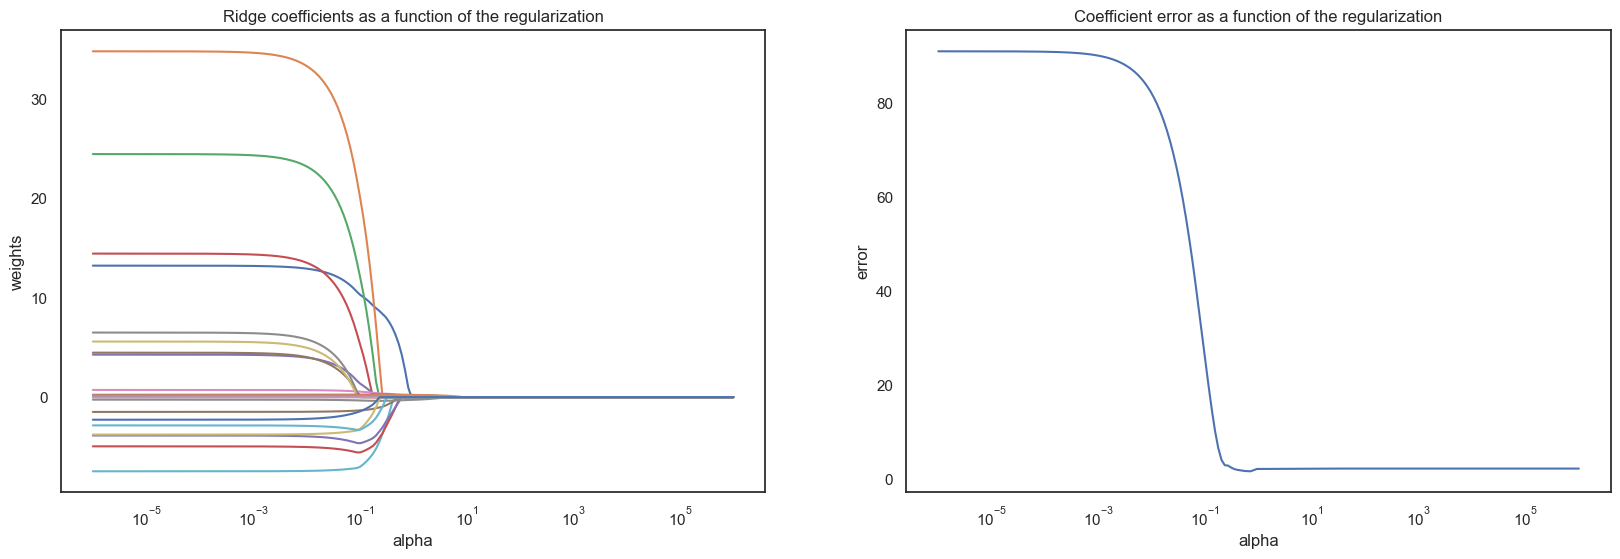

In [248]:
# Display results
plt.figure(figsize = (20, 6))

plt.subplot(121)
ax = plt.gca()
ax.plot(lasso_alphas, coefs)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('weights')
plt.title('Ridge coefficients as a function of the regularization')
plt.axis('tight')

plt.subplot(122)
ax = plt.gca()
ax.plot(lasso_alphas, errors)
ax.set_xscale('log')
plt.xlabel('alpha')
plt.ylabel('error')
plt.title('Coefficient error as a function of the regularization')
plt.axis('tight')

plt.show()

In [250]:
optimal_lasso = LassoCV(alphas=lasso_alphas, cv=10)
optimal_lasso.fit(X_train, y_train)
print('Alpha:', optimal_lasso.alpha_)
print('Score:', optimal_lasso.score(X_test, y_test))

Alpha: 0.13354515629298974
Score: 0.09139074453848639
